# 🚀 Level 3: Task 2 - Sentiment Analysis using Support Vector Machine (SVM)
### 🕵️ Data Exploration & Preparation
In this task, we aim to classify text sentiments. Since SVM models require numerical input, we will use **TF-IDF Vectorization** to convert text into a format the model can understand.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('3) Sentiment dataset.csv')

In [4]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


### 🧹 Step 1: Data Cleaning & Handling Missing Values
In this step, we check for any missing values (NaNs). Since text classification relies on the presence of words, any row with a missing `Text` or `Sentiment` is unusable and should be removed. We also drop unnecessary columns that don't contribute to sentiment (like User, Platform, and Country).

In [9]:
cols_to_drop = ['Unnamed: 0', 'Unnamed: 0.1 ','Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

### ❓ Why did we drop these columns?
In Sentiment Analysis, our primary goal is to understand the **linguistic context** of the message. 

1. **Irrelevant Features:** Columns like `User`, `Platform`, and `Timestamp` do not carry emotional weight. A happy post is happy whether it's posted on Twitter or Facebook.
2. **Metadata vs. Content:** `Country` and `Hashtags` are metadata. While they provide context, the core sentiment is hidden within the `Text` column.
3. **Avoiding Bias:** Using `Likes` or `Retweets` could confuse the model. A post might have many likes but still express a negative sentiment (e.g., sharing a sad news story). 
**Decision:** To build a robust NLP model, we focus only on the **Text** (Features) and **Sentiment** (Target).

In [10]:
print("Null values before cleaning:\n", df.isnull().sum())

Null values before cleaning:
 Unnamed: 0.1    0
Text            0
Sentiment       0
dtype: int64


### 🔢 Step 2: Label Encoding
Machine learning models cannot process raw text labels like "Positive" or "Negative". We use `LabelEncoder` to convert these categories into numerical format (e.g., Positive=2, Neutral=1, Negative=0).

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sentiment_Encoded'] = le.fit_transform(df['Sentiment'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Sentiment Mapping:", mapping)

Sentiment Mapping: {' Acceptance   ': 0, ' Acceptance      ': 1, ' Accomplishment ': 2, ' Admiration ': 3, ' Admiration   ': 4, ' Admiration    ': 5, ' Adoration    ': 6, ' Adrenaline     ': 7, ' Adventure ': 8, ' Affection    ': 9, ' Amazement ': 10, ' Ambivalence ': 11, ' Ambivalence     ': 12, ' Amusement    ': 13, ' Amusement     ': 14, ' Anger        ': 15, ' Anticipation ': 16, ' Anticipation  ': 17, ' Anxiety   ': 18, ' Anxiety         ': 19, ' Appreciation  ': 20, ' Apprehensive ': 21, ' Arousal       ': 22, ' ArtisticBurst ': 23, ' Awe ': 24, ' Awe    ': 25, ' Awe          ': 26, ' Awe           ': 27, ' Bad ': 28, ' Betrayal ': 29, ' Betrayal      ': 30, ' Bitter       ': 31, ' Bitterness ': 32, ' Bittersweet ': 33, ' Blessed       ': 34, ' Boredom ': 35, ' Boredom         ': 36, ' Breakthrough ': 37, ' Calmness     ': 38, ' Calmness      ': 39, ' Captivation ': 40, ' Celebration ': 41, ' Celestial Wonder ': 42, ' Challenge ': 43, ' Charm ': 44, ' Colorful ': 45, ' Compassion

As we discovered, the `Sentiment` column has many duplicate categories due to leading/trailing white spaces (e.g., ' Happy ' vs 'Happy'). We must **strip** these spaces and unify the labels to reduce the number of classes and improve model accuracy.

In [14]:
df['Sentiment'] = df['Sentiment'].str.strip()
unique_sentiments = df['Sentiment'].nunique()
print(f"Unique sentiments after stripping spaces: {unique_sentiments}")



Unique sentiments after stripping spaces: 191


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sentiment_Encoded'] = le.fit_transform(df['Sentiment'])
new_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nNew Cleaned Mapping:", new_mapping)


New Cleaned Mapping: {'Acceptance': 0, 'Accomplishment': 1, 'Admiration': 2, 'Adoration': 3, 'Adrenaline': 4, 'Adventure': 5, 'Affection': 6, 'Amazement': 7, 'Ambivalence': 8, 'Amusement': 9, 'Anger': 10, 'Anticipation': 11, 'Anxiety': 12, 'Appreciation': 13, 'Apprehensive': 14, 'Arousal': 15, 'ArtisticBurst': 16, 'Awe': 17, 'Bad': 18, 'Betrayal': 19, 'Bitter': 20, 'Bitterness': 21, 'Bittersweet': 22, 'Blessed': 23, 'Boredom': 24, 'Breakthrough': 25, 'Calmness': 26, 'Captivation': 27, 'Celebration': 28, 'Celestial Wonder': 29, 'Challenge': 30, 'Charm': 31, 'Colorful': 32, 'Compassion': 33, 'Compassionate': 34, 'Confidence': 35, 'Confident': 36, 'Confusion': 37, 'Connection': 38, 'Contemplation': 39, 'Contentment': 40, 'Coziness': 41, 'Creative Inspiration': 42, 'Creativity': 43, 'Culinary Adventure': 44, 'CulinaryOdyssey': 45, 'Curiosity': 46, 'Darkness': 47, 'Dazzle': 48, 'Desolation': 49, 'Despair': 50, 'Desperation': 51, 'Determination': 52, 'Devastated': 53, 'Disappointed': 54, 'D

Sentiment Grouping (Mapping to Binary/Ternary)
The dataset contains 191 unique emotional labels. Training a model on 191 classes would lead to high complexity and low accuracy (Overfitting). 

To follow the project requirements for **Binary Classification**, we will map these specific emotions into broader categories:
- **Positive:** (Joy, Happiness, Success, Love, etc.)
- **Negative:** (Anger, Sadness, Grief, Hate, etc.)
- **Neutral:** (Neutral, Indifference, etc.)

In [16]:
positive_emotions = ['Acceptance', 'Accomplishment', 'Admiration', 'Adoration', 'Adventure', 'Affection', 'Amazement', 'Amusement', 'Anticipation', 'Appreciation', 'Awe', 'Blessed', 'Celebration', 'Confidence', 'Contentment', 'Creativity', 'Ecstasy', 'Elation', 'Euphoria', 'Excitement', 'Gratitude', 'Happiness', 'Happy', 'Joy', 'Love', 'Optimism', 'Positive', 'Success', 'Triumph']
negative_emotions = ['Anger', 'Anxiety', 'Apprehensive', 'Bad', 'Betrayal', 'Bitter', 'Bitterness', 'Confusion', 'Despair', 'Detachment', 'Disappointed', 'Disgust', 'Fear', 'Frustration', 'Grief', 'Hate', 'Heartbreak', 'Loneliness', 'Negative', 'Regret', 'Sad', 'Sadness', 'Sorrow', 'Suffering']

def categorize_sentiment(sentiment):
    if sentiment in positive_emotions:
        return 1
    elif sentiment in negative_emotions:
        return 0 
    else:
        return 2 
df['Binary_Sentiment'] = df['Sentiment'].apply(categorize_sentiment)
df_binary = df[df['Binary_Sentiment'] != 2].copy()
print("New Distribution:\n", df_binary['Binary_Sentiment'].value_counts())

New Distribution:
 Binary_Sentiment
1    248
0    110
Name: count, dtype: int64


### 📊 Step 3: Feature Extraction using TF-IDF
Since the SVM model cannot process raw text, we convert the `Clean_Text` into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**.
- **Why TF-IDF?** It reflects how important a word is to a document in a collection. It helps the model ignore common words (the, a, is) and focus on words that carry sentiment (amazing, terrible, love).

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
vectorizer = TfidfVectorizer(max_features=1500, stop_words='english')
X = vectorizer.fit_transform(df_binary['Sentiment'])
y = df_binary['Binary_Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Number of features (words) extracted: {X.shape[1]}")

Number of features (words) extracted: 52


### 🤖 Step 4: Support Vector Machine (SVM) Training
In this step, we train the SVM model using two different **Kernels**. 
- **Linear Kernel:** Best for text data because it works well when the number of features (words) is large.
- **RBF (Gaussian) Kernel:** A non-linear kernel that can find more complex boundaries.
We compare them to see which one "understands" our sentiment data better.

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm_linear = SVC(kernel='linear', probability=True)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
svm_rbf = SVC(kernel='rbf', probability=True)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
print(f"Linear SVM Accuracy: {accuracy_score(y_test, y_pred_linear)*100:.2f}%")
print(f"RBF SVM Accuracy: {accuracy_score(y_test, y_pred_rbf)*100:.2f}%")

Linear SVM Accuracy: 98.61%
RBF SVM Accuracy: 98.61%


### 📋 Step 5: Detailed Model Evaluation
To fully evaluate our model as per the requirements, we look at:
1. **Precision & Recall:** To see how many sentiments were correctly identified.
2. **AUC Score:** To measure the model's ability to distinguish between classes.
3. **Confusion Matrix:** To visualize where the model gets confused.

--- Detailed Classification Report (Linear SVM) ---
              precision    recall  f1-score   support

    Negative       1.00      0.95      0.98        21
    Positive       0.98      1.00      0.99        51

    accuracy                           0.99        72
   macro avg       0.99      0.98      0.98        72
weighted avg       0.99      0.99      0.99        72

AUC Score: 1.00


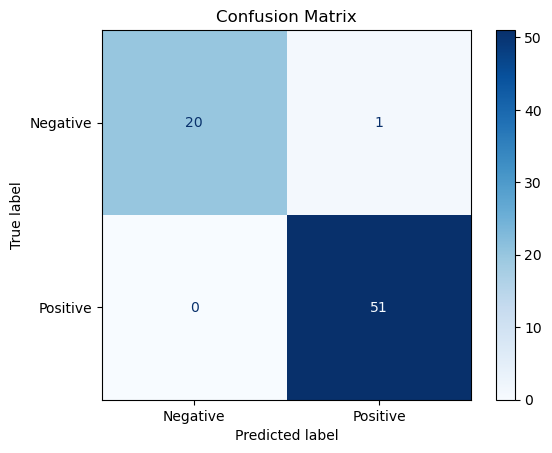

In [21]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("--- Detailed Classification Report (Linear SVM) ---")
print(classification_report(y_test, y_pred_linear, target_names=['Negative', 'Positive']))
auc = roc_auc_score(y_test, svm_linear.predict_proba(X_test)[:, 1])
print(f"AUC Score: {auc:.2f}")
ConfusionMatrixDisplay.from_estimator(svm_linear, X_test, y_test, display_labels=['Negative', 'Positive'], cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### 🎨 Step 6: Visualizing the Decision Boundary
SVM works by creating a **Hyperplane** (a boundary line) that separates Negative and Positive points. Since we have 52 features, we use **PCA** to reduce them to 2 dimensions so we can visualize the "Decision Boundary" on a 2D plot.

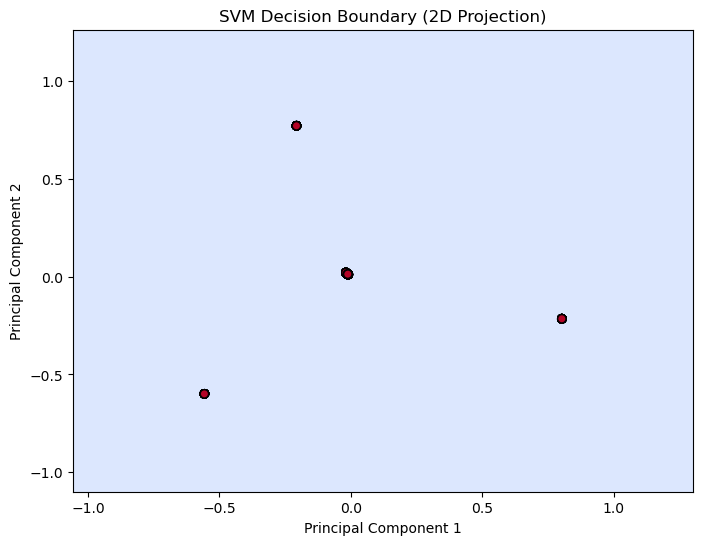

In [22]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train.toarray())

svm_viz = SVC(kernel='linear')
svm_viz.fit(X_train_pca, y_train)

h = .02
x_min, x_max = X_train_pca[:, 0].min() - 0.5, X_train_pca[:, 0].max() + 0.5
y_min, y_max = X_train_pca[:, 1].min() - 0.5, X_train_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("SVM Decision Boundary (2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()